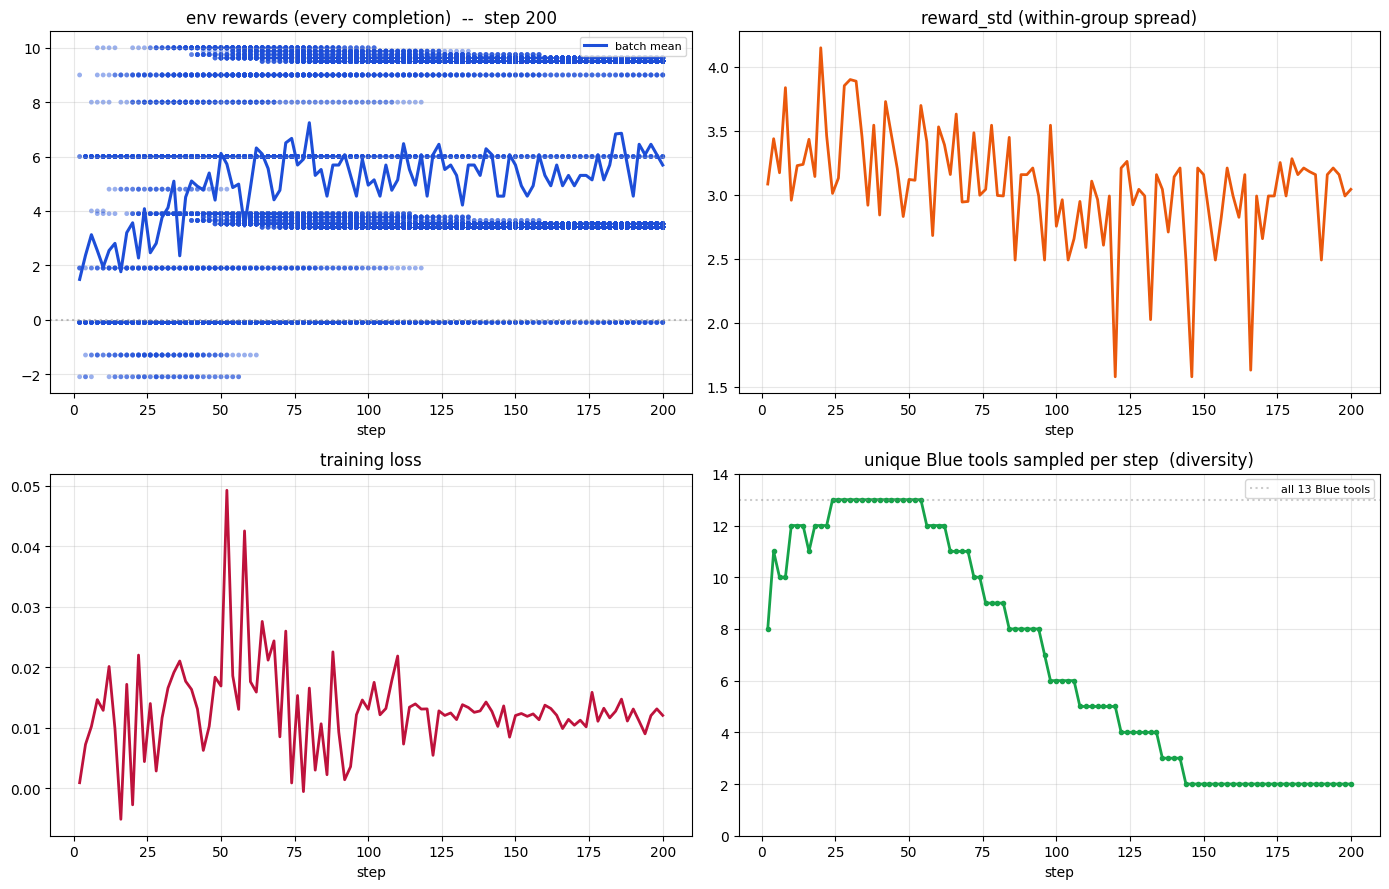

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / compute_rewards / mean,rewards / compute_rewards / std
2,0.000906,1.481250,3.083551,37.750000,36.500000,40.500000,0.000000,37.750000,36.500000,40.500000,0.681550,1.481250,3.083551
4,0.007240,2.368750,3.437381,37.812500,36.500000,40.500000,0.000000,37.812500,36.500000,40.500000,0.618537,2.368750,3.437381
6,0.010194,3.125000,3.171626,38.937500,37.000000,42.000000,0.000000,38.937500,37.000000,42.000000,0.635100,3.125000,3.171626
8,0.014641,2.543750,3.836137,37.812500,35.500000,40.500000,0.000000,37.812500,35.500000,40.500000,0.603136,2.543750,3.836137
10,0.012865,1.931250,2.957124,38.187500,36.000000,40.500000,0.000000,38.187500,36.000000,40.500000,0.620063,1.931250,2.957124
12,0.020116,2.543750,3.227415,38.812500,36.500000,42.500000,0.000000,38.812500,36.500000,42.500000,0.571561,2.543750,3.227415
14,0.009829,2.806250,3.237103,38.750000,36.000000,42.000000,0.000000,38.750000,36.000000,42.000000,0.544268,2.806250,3.237103
16,-0.005136,1.762500,3.432834,38.312500,34.000000,42.500000,0.000000,38.312500,34.000000,42.500000,0.683626,1.762500,3.432834
18,0.017166,3.200000,3.142388,37.812500,35.000000,39.000000,0.000000,37.812500,35.000000,39.000000,0.569368,3.200000,3.142388
20,-0.002748,3.562500,4.147584,38.375000,35.000000,41.000000,0.000000,38.375000,35.000000,41.000000,0.547059,3.562500,4.147584


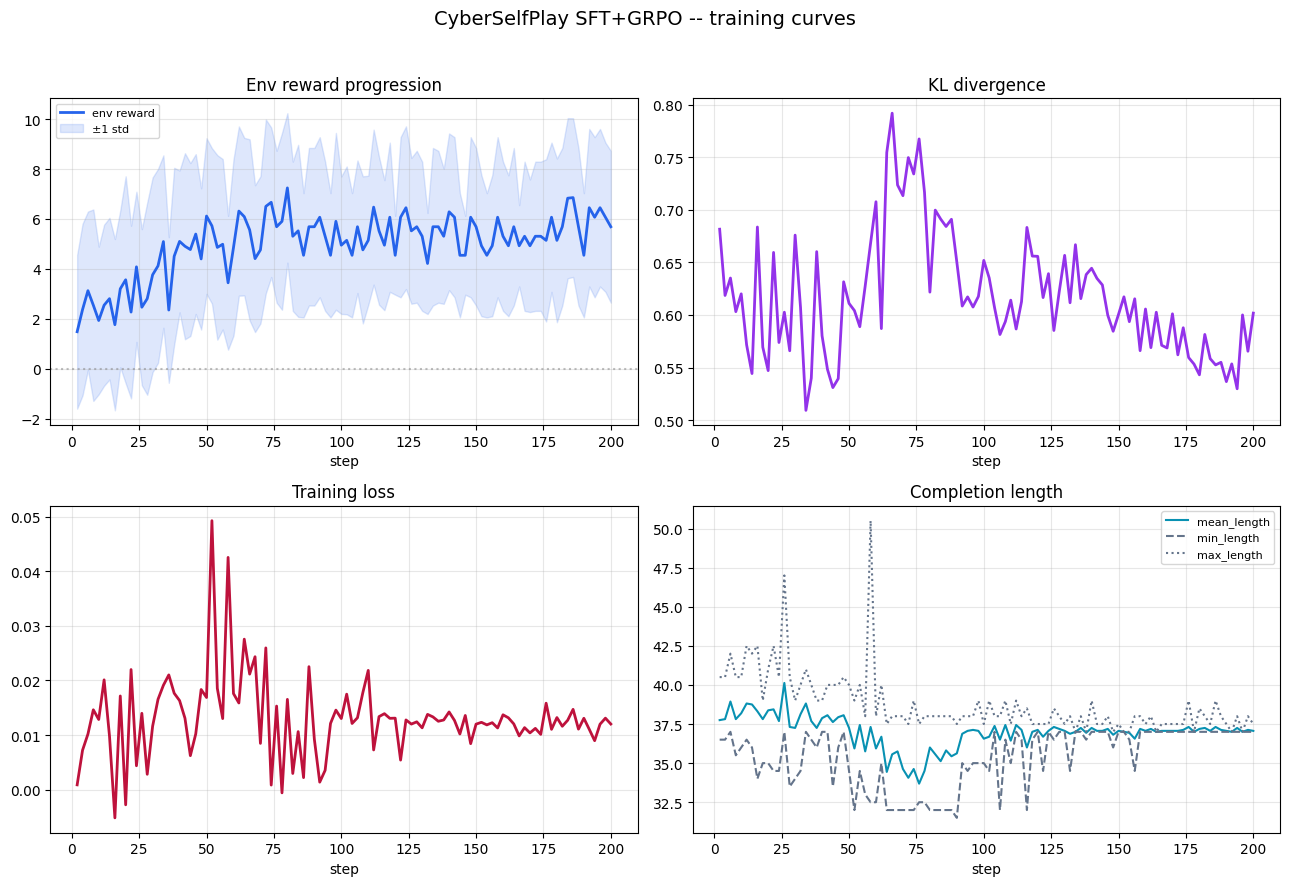

Saved -> /content/outputs_cyber/training_curves.png and /content/outputs_cyber/log_history.json


Unsloth: Restored added_tokens_decoder metadata in /content/outputs_cyber/cyber-blue-grpo-lora/tokenizer_config.json.



Saved LoRA adapter to /content/outputs_cyber/cyber-blue-grpo-lora
[push] skipped -- set HF_TOKEN as a Kaggle Secret to enable.

===== Post-GRPO sanity check =====

--- sample 1 (parse_ok=True) ---
{"actor": "blue", "tool_name": "rotate_secrets", "target": "host-02", "params": {}, "rationale": "encrypt secrets"}
Parsed: {'actor': 'blue', 'tool_name': 'rotate_secrets', 'target': 'host-02', 'params': {}, 'rationale': 'encrypt secrets'}

--- sample 2 (parse_ok=True) ---
{"actor": "blue", "tool_name": "rotate_secrets", "target": "host-02", "params": {}, "rationale": "encrypt secrets"}
Parsed: {'actor': 'blue', 'tool_name': 'rotate_secrets', 'target': 'host-02', 'params': {}, 'rationale': 'encrypt secrets'}

--- sample 3 (parse_ok=True) ---
{"actor": "blue", "tool_name": "rotate_secrets", "target": "host-02", "params": {}, "rationale": "encrypt secrets"}
Parsed: {'actor': 'blue', 'tool_name': 'rotate_secrets', 'target': 'host-02', 'params': {}, 'rationale': 'encrypt secrets'}

Done.


In [ ]:
# =============================================================================
# CyberSelfPlay — Standalone Kaggle SFT + GRPO training (single cell)
#
# Two-phase pipeline (the standard SFT->RL recipe):
#   Phase 1 (SFT):  imitate the heuristic Blue policy on real env rollouts.
#                   Model learns the JSON action schema -- no reward shaping.
#   Phase 2 (GRPO): refine using ONLY the environment's reward signal.
#                   No string-matching tricks, no length bonuses.
#
# Stack: Unsloth 4-bit QLoRA + TRL SFTTrainer + GRPOTrainer + live env.
# Hardware: GPU T4 x2 or P100 (free 30 GPU-h/week on Kaggle).
# Wall-clock: ~10 min SFT + ~25 min GRPO = ~35 min total.
# =============================================================================

# ---------- 1) Install Unsloth + TRL + OpenEnv deps ----------
get_ipython().system('pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"')
get_ipython().system('pip install -q --upgrade git+https://github.com/huggingface/trl.git')
get_ipython().system('pip install -q sympy scipy fastapi uvicorn datasets pydantic openenv-core huggingface_hub matplotlib')

# ---------- 2) Clone your deployed Hugging Face Space ----------
import os, sys, shutil
os.chdir("/content")
shutil.rmtree("/content/cyberselfplay-env", ignore_errors=True)
get_ipython().system('git clone https://huggingface.co/spaces/HarshitShri026/cyberselfplay-env')
os.chdir("/content/cyberselfplay-env")
sys.path.insert(0, "/content/cyberselfplay-env")
get_ipython().system('pip install -q -e .')

# ---------- 3) Wipe any prior checkpoint ----------
shutil.rmtree("/content/cyberselfplay-env/outputs_cyber", ignore_errors=True)

# ---------- 4) Silence noisy warnings ----------
import warnings, logging
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("trl").setLevel(logging.WARNING)

# ---------- 5) Imports (Unsloth FIRST) ----------
import unsloth
import torch, json, random, re
from pathlib import Path
from datasets import Dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig, GRPOConfig, GRPOTrainer

from cyber_selfplay_env.environment import CyberSelfPlayEnvironment
from cyber_selfplay_env.models import CyberAction
from cyber_selfplay_env.tools_blue import BLUE_TOOLS

# ---------- 6) Env vars ----------
os.environ["TRANSFORMERS_VERBOSITY"]    = "error"
os.environ["TOKENIZERS_PARALLELISM"]    = "false"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["WANDB_DISABLED"]            = "true"
os.environ["BITSANDBYTES_NOWELCOME"]    = "1"
if torch.cuda.device_count() > 1:
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
    print("Kaggle T4 x2 detected -- using GPU 0 only (Unsloth single-GPU).")

# ---------- 7) Precision ----------
has_cuda = torch.cuda.is_available()
use_bf16 = has_cuda and torch.cuda.is_bf16_supported()
use_fp16 = has_cuda and not use_bf16
print(f"CUDA: {has_cuda} | bf16: {use_bf16} | fp16: {use_fp16}")
print(f"GPU: {torch.cuda.get_device_name(0) if has_cuda else 'none'}")

# ---------- 8) Model load ----------
MAX_SEQ_LEN = 1024
LORA_RANK   = 16
BASE_MODEL  = "unsloth/Qwen2.5-Coder-1.5B-Instruct-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LEN,
    dtype=None,
    load_in_4bit=True,
)
tokenizer.model_max_length = MAX_SEQ_LEN
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha=LORA_RANK,
    use_gradient_checkpointing="unsloth",
)

# Clear `generation_config.max_length` so it does NOT collide with `max_new_tokens`
# at every `model.generate(...)` call (silences the spammy transformers warning).
if getattr(model, "generation_config", None) is not None:
    model.generation_config.max_length = None
    model.generation_config.max_new_tokens = None

IS_LLAMA = "llama" in BASE_MODEL.lower()
IS_QWEN  = "qwen"  in BASE_MODEL.lower()

# ---------- 9) Prompt builder (single source of truth) + JSON parser ----------
# Both SFT data and GRPO inference go through tokenizer.apply_chat_template
# so the formats are byte-identical. NO hand-written prompt strings anywhere.
VALID_BLUE = list(BLUE_TOOLS)

SYSTEM_MSG = (
    "You are the Blue defender in a cyber self-play game.\n"
    "You MUST output ONLY a valid JSON object.\n"
    "No explanation. No extra text. No prefixes/suffixes.\n"
    "Output exactly ONE JSON object and stop.\n\n"
    f"Schema: {{\"actor\":\"blue\",\"tool_name\":<one of {sorted(VALID_BLUE)}>,"
    "\"target\":\"host-XX\",\"params\":{},\"rationale\":\"short\"}}"
)

def _user_msg(obs_dict: dict) -> str:
    return (
        f"Observation:\n{json.dumps(obs_dict, ensure_ascii=True)}\n\n"
        "Reply with ONE JSON line ending with '}'. Nothing else."
    )

def obs_to_prompt(obs_dict: dict) -> str:
    """Inference prompt. Same chat template SFT used, with assistant header appended."""
    return tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_MSG},
            {"role": "user",   "content": _user_msg(obs_dict)},
        ],
        tokenize=False,
        add_generation_prompt=True,
    )

# JSON_RE = re.compile(r"\{[^{}]*\}", re.DOTALL)

JSON_RE = re.compile(r"\{.*\}", re.DOTALL)

def parse_action(text: str):
    matches = JSON_RE.findall(text)
    if not matches:
        return None, False

    for m in matches:
        try:
            a = json.loads(m)
            if a.get("tool_name") in VALID_BLUE:
                a["actor"] = "blue"
                a.setdefault("target", "host-00")
                a.setdefault("params", {})
                a.setdefault("rationale", "grpo")
                return a, True
        except:
            continue

    return None, False

# =============================================================================
# PHASE 1 -- SFT warm-start (imitate heuristic Blue policy)
# =============================================================================

# ---------- 10) Heuristic Blue policy (lifted from train/colab_trl_selfplay.py) ----------
# Real catalog of `required_tool` values used by the env's instruction system
# (see cyber_selfplay_env/simulator.py::_build_instructions). Picking from this
# list means execute_instruction has a real chance (1/8) of matching.
INSTRUCTION_TOOLS = [
    "triage_alerts", "isolate_host", "deploy_patch", "rotate_secrets",
    "run_forensics", "restore_backup", "harden_policy", "publish_ioc_blocklist",
]

RATIONALE = {
    "query_siem":            "scan telemetry",
    "triage_alerts":         "investigate alert",
    "isolate_host":          "contain breach",
    "disable_account":       "lock compromised user",
    "rotate_secrets":        "remove persistence",
    "deploy_patch":          "harden vulnerable host",
    "harden_policy":         "tighten controls",
    "restore_backup":        "recover service",
    "run_forensics":         "investigate host",
    "publish_ioc_blocklist": "block known IOCs",
    "execute_instruction":   "follow playbook",
    "checkpoint_plan":       "track progress",
    "reconcile_state":       "stabilize state",
}

EPSILON_RANDOM = 0.40  # 40% pure exploration in SFT data => corpus covers all
                       # 13 tools roughly evenly, killing the "default action"
                       # bias that triggers post-SFT mode collapse.

def heuristic_blue_action(public_state: dict, telemetry: list, t_step: int) -> dict:
    """State-conditional, diverse Blue policy.

    The previous version only ever fired ~3 branches and ~80% of the data
    became `execute_instruction`, which caused SFT mode collapse. This version
    builds a *weighted candidate set* from the current observation and samples
    one, plus a 20% epsilon-random arm. Result: the SFT corpus exercises all
    13 Blue tools with realistic targets, so the model learns the schema
    BROADLY and GRPO has real diversity to do credit assignment on.
    """
    detections = telemetry or public_state.get("detections", []) or []
    known      = int(public_state.get("known_incident_count", 0) or 0)
    instr      = public_state.get("instruction_progress", {}) or {}
    instr_pending = isinstance(instr, dict) and instr.get("completed", 0) < instr.get("total", 1)

    rand_host = lambda: f"host-{random.randint(0, 5):02d}"

    # 20% pure exploration: random valid tool with a syntactically correct payload.
    if random.random() < EPSILON_RANDOM:
        tool = random.choice(VALID_BLUE)
        if tool == "execute_instruction":
            target, params = "", {"required_tool": random.choice(INSTRUCTION_TOOLS)}
        elif tool == "disable_account":
            target, params = f"user-{random.randint(0, 3):02d}", {}
        else:
            target, params = rand_host(), {}
        return {"actor": "blue", "tool_name": tool, "target": target,
                "params": params, "rationale": RATIONALE.get(tool, "explore")}

    # Build (tool, target, params, weight) candidates from the observation.
    cands: list[tuple[str, str, dict, int]] = []

    # Always-valid baseline (covers tools that always parse but pay little).
    cands += [
        ("query_siem",       rand_host(), {}, 1),
        ("checkpoint_plan",  rand_host(), {}, 1),
        ("reconcile_state",  rand_host(), {}, 1),
        ("deploy_patch",     rand_host(), {}, 1),
        ("harden_policy",    rand_host(), {}, 1),
        ("publish_ioc_blocklist", rand_host(), {}, 1),
        ("disable_account",  f"user-{random.randint(0, 3):02d}", {}, 1),
    ]

    if detections:
        cands += [("triage_alerts", rand_host(), {}, 3)]   # +2.0 reward when valid

    if known > 0:
        cands += [
            ("isolate_host",   rand_host(), {}, 3),         # +3.0
            ("rotate_secrets", rand_host(), {}, 2),         # +4.0
            ("run_forensics",  rand_host(), {}, 2),
            ("restore_backup", rand_host(), {}, 1),
        ]

    if instr_pending:
        # weight=1 (was 2) -- execute_instruction was over-represented and caused
        # the model to memorize it as the "safe default" action.
        cands += [(
            "execute_instruction", "",
            {"required_tool": random.choice(INSTRUCTION_TOOLS)},
            1,                                              # +1.2 if right, -1.0 if wrong
        )]

    if t_step > 0 and t_step % 10 == 0:
        cands += [("checkpoint_plan", rand_host(), {}, 4)]  # +2.0 on multiples of 10

    # Weighted random sample
    pool = [(tool, tgt, params) for tool, tgt, params, w in cands for _ in range(w)]
    tool, target, params = random.choice(pool)
    return {"actor": "blue", "tool_name": tool, "target": target,
            "params": params, "rationale": RATIONALE.get(tool, "respond")}

# ---------- 11) Collect SFT dataset from real env rollouts ----------
# Uses TRL "messages" format -> chat template applied automatically AND
# prompt tokens are masked from the loss (only JSON tokens contribute).
print("\n===== Phase 1: collecting SFT data from heuristic policy =====")
N_SFT_EPISODES = 50      # ~150 episodes x ~20 steps = ~30000 (obs, action) pairs
RED_TOOLS = ["recon_network", "attempt_exploit", "lateral_move", "exfiltrate_data"]
random.seed(42)

sft_pairs = []
for ep in range(N_SFT_EPISODES):
    env = CyberSelfPlayEnvironment()
    obs = env.reset()
    for t in range(40):
        if obs.done: break
        red_act = CyberAction(actor="red",
                              tool_name=RED_TOOLS[t % len(RED_TOOLS)],
                              target=f"host-{t % 6:02d}", params={})
        red_obs = env.step(red_act)
        if red_obs.done: break
        blue_action_dict = heuristic_blue_action(
            red_obs.public_state, red_obs.telemetry, t,
        )
        obs_payload = {
            "public_state":     red_obs.public_state,
            "telemetry":        red_obs.telemetry,
            "incident_summary": red_obs.incident_summary,
        }
        sft_pairs.append({
            "messages": [
                {"role": "system",    "content": SYSTEM_MSG},
                {"role": "user",      "content": _user_msg(obs_payload)},
                {"role": "assistant", "content": json.dumps(blue_action_dict, ensure_ascii=True)},
            ]
        })
        obs = env.step(CyberAction(**blue_action_dict))
print(f"Collected {len(sft_pairs)} SFT examples in messages format.")

# Print the action distribution -- if any single tool > 50%, SFT will collapse.
from collections import Counter
_dist = Counter(json.loads(p["messages"][-1]["content"])["tool_name"] for p in sft_pairs)
print("\n[SFT] Blue tool distribution in training data:")
for tool, n in _dist.most_common():
    pct = 100 * n / len(sft_pairs)
    bar = "#" * int(pct / 2)
    print(f"  {tool:<22s} {n:>4d}  {pct:5.1f}%  {bar}")
top_pct = max(_dist.values()) / len(sft_pairs)
if top_pct > 0.5:
    print(f"\nWARNING: top tool is {top_pct:.0%} of data -- expect mode collapse.")
else:
    print(f"\n[SFT] Diversity OK -- top tool is only {top_pct:.0%} of corpus.\n")

sft_dataset = Dataset.from_list(sft_pairs)

# Pre-apply the chat template -> Unsloth's SFTTrainer wants plain text input.
def _msgs_to_text(example):
    return {"text": tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )}

sft_dataset = sft_dataset.map(_msgs_to_text, remove_columns=["messages"])
print("Sample SFT text:\n", sft_dataset[0]["text"][:400], "...\n")

# ---------- 12) SFT phase ----------
print("\n===== Phase 1: SFT (imitation learning, BFD-packed) =====")
sft_args = SFTConfig(
    output_dir                  = "/content/outputs_cyber/sft",
    learning_rate               = 2e-4,
    per_device_train_batch_size = 4,
    gradient_accumulation_steps = 4,
    num_train_epochs            = 2,
    logging_steps               = 1,
    warmup_steps                = 5,
    optim                       = "adamw_8bit",
    bf16                        = use_bf16,
    fp16                        = use_fp16,
    save_strategy               = "no",
    report_to                   = "none",
    max_length                  = MAX_SEQ_LEN,
    dataset_text_field          = "text",
    packing                     = True,
    packing_strategy            = "bfd",
)
sft_trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    args          = sft_args,
    train_dataset = sft_dataset,
)
sft_trainer.train()
print("SFT done.")

# ---------- 13) Sanity check after SFT (parses should be ~100%) ----------
# Use GREEDY decoding -- this is the truest signal of what SFT actually learned.
# Vary the env trajectory length per sample so you see different observations
# (and therefore different outputs), not 8 copies of the same one.
print("\n===== Post-SFT sanity check (greedy decoding, varied env states) =====")
FastLanguageModel.for_inference(model)
ok_count, n_check = 0, 8
example_prompt, example_gen = None, None
RED_T = ["recon_network", "attempt_exploit", "lateral_move", "exfiltrate_data"]
for i in range(n_check):
    env_t = CyberSelfPlayEnvironment(); env_t.reset()
    for t in range(random.randint(1, 6)):
        env_t.step(CyberAction(actor="red",
                               tool_name=RED_T[t % len(RED_T)],
                               target=f"host-{random.randint(0,5):02d}"))
    o = env_t.step(CyberAction(actor="red", tool_name="recon_network",
                               target=f"host-{random.randint(0,5):02d}"))
    p = obs_to_prompt({"public_state": o.public_state, "telemetry": o.telemetry,
                       "incident_summary": o.incident_summary})
    inp = tokenizer(p, return_tensors="pt").to(model.device)
    out = model.generate(
        **inp,
        max_new_tokens=128,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)
    _, ok = parse_action(gen)
    ok_count += int(ok)
    print(f"sample {i+1} (parses={ok}): {gen.strip()[:200]}")
    if example_prompt is None:
        example_prompt, example_gen = p, gen

parse_rate = ok_count / n_check
print(f"\nSFT parse rate: {ok_count}/{n_check} = {parse_rate:.0%}")

if parse_rate < 0.5:
    # Print one full prompt + generation so the user can SEE what the model is doing.
    print("\n--- DEBUG: full inference prompt the model is being given ---")
    print(example_prompt)
    print("--- DEBUG: full model output ---")
    print(example_gen)
    print("--- DEBUG: example SFT training text ---")
    print(sft_dataset[0]["text"][:1500])
    print("--- end debug ---\n")
    raise RuntimeError(
        f"SFT parse rate too low ({parse_rate:.0%}). "
        "GRPO will not learn -- aborting.\n"
        "Fixes: (a) increase N_SFT_EPISODES (50 -> 100), "
        "(b) increase num_train_epochs (4 -> 6), "
        "(c) try a stronger BASE_MODEL (Qwen2.5-Coder-1.5B-Instruct-bnb-4bit)."
    )
FastLanguageModel.for_training(model)

# =============================================================================
# PHASE 2 -- GRPO refinement (env reward only, NO hand-crafted shaping)
# =============================================================================
print("\n===== Phase 2: GRPO with environment reward only =====")

# ---------- 14) Build GRPO prompts from real env states ----------
N_PROMPTS = 64
prompts = []
for _ in range(N_PROMPTS):
    env = CyberSelfPlayEnvironment(); env.reset()
    for _ in range(random.randint(0, 4)):
        env.step(CyberAction(actor="red", tool_name="attempt_exploit",
                             target=f"host-{random.randint(0,5):02d}"))
    o = env.step(CyberAction(actor="red", tool_name="recon_network", target="host-00"))
    prompts.append({"prompt": obs_to_prompt({
        "public_state": o.public_state, "telemetry": o.telemetry,
        "incident_summary": o.incident_summary,
    })})
train_dataset = Dataset.from_list(prompts)
print(f"Built {len(train_dataset)} GRPO prompts.")

# ---------- 15) Reward = environment reward + diversity shaping ----------
# Reward design:
#   1. base   = env.step(action).reward                    (pure env signal)
#   2. -0.5  if same tool dominates this in-batch group    (anti-collapse)
#   3. -0.2  if tool == "execute_instruction"              (counter SFT bias)
#   4. -1.0  if completion is unparseable                  (format failure)
#
# (2) is GROUP-AWARE: GRPO sends `num_generations` rollouts per prompt; we
# penalize each completion by how often its tool repeats inside that group.
# This directly attacks "always same action" without poisoning the env signal.
INVALID_PENALTY      = -1.0
DUP_TOOL_PENALTY     = -0.5
INSTR_TOOL_PENALTY   = -0.2

_REWARD_CALLS  = {"n": 0}
_PER_STEP      = []   # list of {step, rewards: [...], tools: [...]} per call

def compute_rewards(prompts, completions, **kwargs):
    n          = len(completions)
    base       = [0.0] * n
    tools      = [None] * n     # tool_name (or None if unparseable)
    parsed_ok  = [False] * n
    debug_text = None

    for i, comp in enumerate(completions):
        text = comp if isinstance(comp, str) else comp.get("content", "")
        if debug_text is None:
            debug_text = text
        action, ok = parse_action(text)
        if not ok:
            base[i] = INVALID_PENALTY
            continue
        env = CyberSelfPlayEnvironment(); env.reset()
        env.step(CyberAction(actor="red", tool_name="attempt_exploit", target="host-01"))
        try:
            obs = env.step(CyberAction(**action))
            base[i]      = float(obs.reward or 0.0)
            tools[i]     = action.get("tool_name")
            parsed_ok[i] = True
        except Exception:
            base[i] = INVALID_PENALTY

    # --- group-aware diversity penalty (within this compute_rewards call) ---
    # Heavy when one tool > 50% of valid completions; zero when fully diverse.
    from collections import Counter
    counts   = Counter(t for t in tools if t)
    n_valid  = sum(1 for t in tools if t)
    rewards  = []
    for i in range(n):
        r = base[i]
        if parsed_ok[i] and tools[i]:
            share = counts[tools[i]] / max(1, n_valid)
            if share > 0.5:                          # this tool is dominating
                r += DUP_TOOL_PENALTY * (share - 0.5) * 2  # 0..-0.5 ramp
            if tools[i] == "execute_instruction":
                r += INSTR_TOOL_PENALTY              # discourage SFT-bias action
        rewards.append(r)

    # --- bookkeeping for per-step plot ---
    _REWARD_CALLS["n"] += 1
    _PER_STEP.append({
        "call":    _REWARD_CALLS["n"],
        "rewards": rewards,
        "tools":   tools,
        "parsed":  sum(parsed_ok),
        "n":       n,
        "tool_dist": dict(counts),
    })

    if _REWARD_CALLS["n"] % 5 == 1 and debug_text:
        top = ", ".join(f"{k}={v}" for k, v in counts.most_common(3))
        print(f"[rewards] call={_REWARD_CALLS['n']:3d} parsed={sum(parsed_ok)}/{n} "
              f"r=[{min(rewards):+.2f},{max(rewards):+.2f}] mean={sum(rewards)/n:+.2f} "
              f"top_tools={{{top}}} sample={debug_text.strip()[:140]!r}", flush=True)
    return rewards

# ---------- 16) Live plot + per-step print + per-step image/log dump ----------
# At every logging step we:
#   * append a row to train_metrics.log
#   * append the FULL per-completion reward/tool list to per_step_rewards.jsonl
#   * write a NEW PNG curves/step_XXXX.png  (one file per step, never overwritten)
#   * also keep curves/latest.png as a convenience pointer to the most recent
from transformers import TrainerCallback
from IPython.display import clear_output
import matplotlib.pyplot as plt

OUT_DIR     = Path("/content/outputs_cyber")
CURVES_DIR  = OUT_DIR / "curves"             # one PNG per logging step lives here
LOG_FILE    = OUT_DIR / "train_metrics.log"
JSONL_FILE  = OUT_DIR / "per_step_rewards.jsonl"
LATEST_PNG  = CURVES_DIR / "latest.png"      # convenience pointer (also rewritten)

class LivePlotCallback(TrainerCallback):
    def __init__(self):
        self.h = []                # one row per logging step
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        CURVES_DIR.mkdir(parents=True, exist_ok=True)
        LOG_FILE.write_text("step\tloss\treward\treward_min\treward_max\treward_std\tkl\tmean_len\tn_unique_tools\n")
        JSONL_FILE.write_text("")  # truncate

    def on_log(self, args, state, control, logs=None, **kw):
        if not logs or "reward" not in logs: return

        # Pull individual rewards from the latest compute_rewards call(s).
        # GRPO calls compute_rewards once per micro-batch; we may have several
        # calls per logging step (when grad-accum > 1). Aggregate them.
        recent_calls = _PER_STEP[len(self.h):]   # everything since last log
        flat_rewards = [r for c in recent_calls for r in c["rewards"]]
        flat_tools   = [t for c in recent_calls for t in c["tools"] if t]
        unique_tools = len(set(flat_tools))
        rmin = min(flat_rewards) if flat_rewards else 0.0
        rmax = max(flat_rewards) if flat_rewards else 0.0

        row = {
            **logs,
            "step":         state.global_step,
            "reward_min":   rmin,
            "reward_max":   rmax,
            "individuals":  flat_rewards,
            "tools":        flat_tools,
            "n_unique_tools": unique_tools,
        }
        self.h.append(row)

        loss     = row.get("loss", row.get("train_loss", 0.0))
        rmean    = row.get("reward", 0.0)
        rstd     = row.get("reward_std", 0.0)
        meanlen  = row.get("completions/mean_length", 0.0)
        kl       = row.get("kl", 0.0)

        line = (f"[step {state.global_step:>4d}] "
                f"loss={loss:+.4f}  reward(mean/min/max)={rmean:+.2f}/{rmin:+.2f}/{rmax:+.2f}  "
                f"std={rstd:.2f}  kl={kl:.4f}  len={meanlen:.0f}  unique_tools={unique_tools}")
        print(line, flush=True)

        with LOG_FILE.open("a") as f:
            f.write(f"{state.global_step}\t{loss:.6f}\t{rmean:.6f}\t{rmin:.6f}\t{rmax:.6f}"
                    f"\t{rstd:.6f}\t{kl:.6f}\t{meanlen:.3f}\t{unique_tools}\n")
        with JSONL_FILE.open("a") as f:
            f.write(json.dumps({
                "step": state.global_step,
                "rewards": flat_rewards,
                "tools":   flat_tools,
            }) + "\n")

        clear_output(wait=True)
        fig, ax = plt.subplots(2, 2, figsize=(14, 9))

        # (0,0) ALL individual rewards as scatter + mean line
        for i, r in enumerate(self.h):
            xs = [r["step"]] * len(r["individuals"])
            ax[0,0].scatter(xs, r["individuals"], s=12, alpha=0.45, c="#1d4ed8",
                            edgecolors="none")
        steps     = [r["step"] for r in self.h]
        means     = [r.get("reward", 0) for r in self.h]
        ax[0,0].plot(steps, means, color="#1d4ed8", linewidth=2.2, label="batch mean")
        ax[0,0].axhline(0, color="gray", ls=":", alpha=0.5)
        ax[0,0].set_title(f"env rewards (every completion)  --  step {state.global_step}")
        ax[0,0].set_xlabel("step"); ax[0,0].grid(alpha=0.3); ax[0,0].legend(fontsize=8)

        # (0,1) reward std
        ax[0,1].plot(steps, [r.get("reward_std", 0) for r in self.h],
                     color="#ea580c", linewidth=2)
        ax[0,1].set_title("reward_std (within-group spread)"); ax[0,1].set_xlabel("step")
        ax[0,1].grid(alpha=0.3)

        # (1,0) training loss
        ax[1,0].plot(steps, [r.get("loss", r.get("train_loss", 0.0)) for r in self.h],
                     color="#be123c", linewidth=2)
        ax[1,0].set_title("training loss"); ax[1,0].set_xlabel("step"); ax[1,0].grid(alpha=0.3)

        # (1,1) unique tools sampled per step  ==> the diversity meter
        ax[1,1].plot(steps, [r["n_unique_tools"] for r in self.h],
                     color="#16a34a", linewidth=2, marker="o", markersize=3)
        ax[1,1].axhline(13, color="gray", ls=":", alpha=0.4, label="all 13 Blue tools")
        ax[1,1].set_ylim(0, 14)
        ax[1,1].set_title("unique Blue tools sampled per step  (diversity)")
        ax[1,1].set_xlabel("step"); ax[1,1].grid(alpha=0.3); ax[1,1].legend(fontsize=8)

        plt.tight_layout()
        # One PNG per step, NEVER overwritten -- you keep the full history.
        step_png = CURVES_DIR / f"step_{state.global_step:05d}.png"
        fig.savefig(step_png,   dpi=110, bbox_inches="tight")
        fig.savefig(LATEST_PNG, dpi=110, bbox_inches="tight")  # convenience pointer
        plt.show()

# ---------- 17) GRPO config ----------
# Anti-collapse settings:
#   * temperature=1.0 (was 0.9)  -> max policy entropy during sampling
#   * top_p=0.95                  -> still avoids low-prob nonsense
#   * num_generations=8           -> 8 samples per prompt; combined with the
#                                    in-group diversity penalty in compute_rewards,
#                                    the model gets a clear gradient toward variety.
#   * beta=0.02                   -> gentle KL to keep us close to the SFT prior
training_args = GRPOConfig(
    output_dir                  = "/content/outputs_cyber",
    learning_rate               = 5e-6,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    num_generations             = 8,
    max_completion_length       = 128,
    max_steps                   = 200,
    logging_steps               = 2,
    warmup_steps                = 10,
    optim                       = "adamw_8bit",
    bf16                        = use_bf16,
    fp16                        = use_fp16,
    use_cpu                     = not has_cuda,
    save_steps                  = 20,
    report_to                   = "none",
    temperature                 = 1.0,
    top_p                       = 0.95,
    beta                        = 0.02,
    max_grad_norm               = 1.0,
)

# ---------- 18) Train ----------
trainer = GRPOTrainer(
    model         = model,
    reward_funcs  = [compute_rewards],
    args          = training_args,
    train_dataset = train_dataset,
    callbacks     = [LivePlotCallback()],
)
trainer.train()

# ---------- 19) Final summary plot + raw metrics dump ----------
OUT = Path(training_args.output_dir)
OUT.mkdir(parents=True, exist_ok=True)
history = list(trainer.state.log_history or [])
(OUT / "log_history.json").write_text(json.dumps(history, indent=2))

def _series(key):
    xs, ys = [], []
    for r in history:
        if key in r and "step" in r:
            xs.append(r["step"]); ys.append(r[key])
    return xs, ys

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("CyberSelfPlay SFT+GRPO -- training curves", fontsize=14)

ax = axes[0, 0]
rx, ry = _series("reward"); sx, sy = _series("reward_std")
if rx: ax.plot(rx, ry, color="#2563eb", linewidth=2, label="env reward")
if sx and len(ry) == len(sy):
    ax.fill_between(sx, [m-s for m,s in zip(ry,sy)], [m+s for m,s in zip(ry,sy)],
                    color="#2563eb", alpha=0.15, label="±1 std")
ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Env reward progression"); ax.set_xlabel("step")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
kx, ky = _series("kl")
if kx: ax.plot(kx, ky, color="#9333ea", linewidth=2)
ax.set_title("KL divergence"); ax.set_xlabel("step"); ax.grid(alpha=0.3)

ax = axes[1, 0]
lx, ly = _series("loss")
if not lx: lx, ly = _series("train_loss")
if lx: ax.plot(lx, ly, color="#be123c", linewidth=2)
ax.set_title("Training loss"); ax.set_xlabel("step"); ax.grid(alpha=0.3)

ax = axes[1, 1]
for k, color, ls in [("completions/mean_length", "#0891b2", "-"),
                     ("completions/min_length",  "#64748b", "--"),
                     ("completions/max_length",  "#64748b", ":")]:
    xs, ys = _series(k)
    if xs: ax.plot(xs, ys, color=color, linestyle=ls, label=k.split("/")[-1])
ax.set_title("Completion length"); ax.set_xlabel("step")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUT / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {OUT/'training_curves.png'} and {OUT/'log_history.json'}")

# ---------- 20) Save adapter ----------
SAVE_DIR = "/content/outputs_cyber/cyber-blue-grpo-lora"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\nSaved LoRA adapter to {SAVE_DIR}")

# ---------- 21) (Optional) Push to HF Hub ----------
PUSH_TO_HUB    = True
HF_TARGET_REPO = "HarshitShri026/cyber-blue-grpo"

try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    HF_TOKEN = ""

if PUSH_TO_HUB and HF_TOKEN:
    from huggingface_hub import HfApi, login
    login(token=HF_TOKEN)
    api = HfApi()
    api.create_repo(repo_id=HF_TARGET_REPO, repo_type="model", exist_ok=True)
    api.upload_folder(repo_id=HF_TARGET_REPO, folder_path=SAVE_DIR, repo_type="model")
    # Top-level training artifacts.
    for fname in ("training_curves.png", "log_history.json", "train_metrics.log",
                  "per_step_rewards.jsonl"):
        fpath = OUT / fname
        if fpath.exists():
            api.upload_file(path_or_fileobj=str(fpath), path_in_repo=fname,
                            repo_id=HF_TARGET_REPO, repo_type="model")
    # Per-step PNGs (one image per logging step) -> uploaded under curves/.
    if CURVES_DIR.exists():
        api.upload_folder(repo_id=HF_TARGET_REPO, folder_path=str(CURVES_DIR),
                          path_in_repo="curves", repo_type="model")
    print(f"Uploaded -> https://huggingface.co/{HF_TARGET_REPO}")
    print(f"  per-step curves -> https://huggingface.co/{HF_TARGET_REPO}/tree/main/curves")
else:
    print("[push] skipped -- set HF_TOKEN as a Kaggle Secret to enable.")

# ---------- 22) Final sanity check (varied env states) ----------
print("\n===== Post-GRPO sanity check =====")
FastLanguageModel.for_inference(model)
for i in range(3):
    env_t = CyberSelfPlayEnvironment(); env_t.reset()
    for t in range(random.randint(1, 6)):
        env_t.step(CyberAction(actor="red",
                               tool_name=RED_T[t % len(RED_T)],
                               target=f"host-{random.randint(0,5):02d}"))
    o = env_t.step(CyberAction(actor="red", tool_name="recon_network",
                               target=f"host-{random.randint(0,5):02d}"))
    p = obs_to_prompt({"public_state": o.public_state, "telemetry": o.telemetry,
                       "incident_summary": o.incident_summary})
    inp = tokenizer(p, return_tensors="pt").to(model.device)
    out = model.generate(
        **inp,
        max_new_tokens=128,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)
    action, ok = parse_action(gen)
    print(f"\n--- sample {i+1} (parse_ok={ok}) ---")
    print(gen.strip()); print("Parsed:", action)
print("\nDone.")
